# 산학프로젝트
**제조 공정 품질 불량 예측**

# 04_1_Imbalance_and_Feature_Experiments

- 불균형 처리와 특징 실험, 후보 축소 (스크리닝)
- 평가 프로토콜: 80/20 단일 분할 (`random_state=0`), test set 1046건 / 불량 12건
- 주의: 여기 수치는 후보 비교용, 보고 수치는 04_6 반복 CV 기준

## import

In [1]:
import pandas as pd
import numpy as np
import os

## 경로설정

In [2]:
os.chdir("data")

## 데이터 불러오기

In [3]:
# 02_EDA에서 저장한 전처리 데이터
# - 기록 오류 보정, 중복 제거, CN7·RG3 한정, PassOrFail 인코딩(양품 0 / 불량 1), Part 파생까지 끝난 상태
model_data=pd.read_csv('labeled_modeling.csv', index_col=0)

print(f'{model_data.shape[0]}행 {model_data.shape[1]}컬럼 / 불량 {int(model_data["PassOrFail"].sum())}건')

result_df=pd.read_csv('03_Baseline_Modeling_Result.csv')

5230행 30컬럼 / 불량 60건


In [4]:
model_data.head()

,TimeStamp,PART_FACT_PLAN_DATE,PART_FACT_SERIAL,PART_NAME,EQUIP_CD,PassOrFail,Injection_Time,Filling_Time,Plasticizing_Time,Cycle_Time,...,Barrel_Temperature_1,Barrel_Temperature_2,Barrel_Temperature_3,Barrel_Temperature_4,Barrel_Temperature_5,Barrel_Temperature_6,Hopper_Temperature,Mold_Temperature_3,Mold_Temperature_4,Part
0,2020-10-16 04:57:47,2020-10-16 오전 12:00:00,24,CN7 W/S SIDE MLD'G RH,S14,0,9.59,4.47,16.92,59.520000,...,276.500000,274.700012,274.799988,269.200012,255.000000,229.699997,66.300003,24.799999,27.5,CN7RH
1,2020-10-16 04:58:48,2020-10-16 오전 12:00:00,24,CN7 W/S SIDE MLD'G RH,S14,0,9.60,4.48,16.91,59.580002,...,276.200012,275.500000,275.299988,270.799988,254.699997,229.500000,67.199997,24.799999,27.6,CN7RH
2,2020-10-16 04:58:48,2020-10-16 오전 12:00:00,23,CN7 W/S SIDE MLD'G LH,S14,0,9.60,4.48,16.91,59.580002,...,276.200012,275.500000,275.299988,270.799988,254.699997,229.500000,67.199997,24.799999,27.6,CN7LH
3,2020-10-16 04:59:48,2020-10-16 오전 12:00:00,23,CN7 W/S SIDE MLD'G LH,S14,0,9.59,4.48,16.91,59.560001,...,276.500000,275.000000,275.399994,271.100006,254.899994,230.000000,66.900002,25.000000,27.6,CN7LH
4,2020-10-16 04:59:48,2020-10-16 오전 12:00:00,24,CN7 W/S SIDE MLD'G RH,S14,0,9.59,4.48,16.91,59.560001,...,276.500000,275.000000,275.399994,271.100006,254.899994,230.000000,66.900002,25.000000,27.6,CN7RH


In [5]:
result_df

,Model,Defect Precision,Defect Recall,Defect F1 Score,Average Precision
0,RandomForest Baseline,0.294118,0.416667,0.344828,0.444250
1,Bagging Baseline,0.368421,0.583333,0.451613,0.441911
2,XGBoost Baseline,0.368421,0.583333,0.451613,0.270144


## 모델 개선 실험

In [6]:
# 개선 실험 공통 라이브러리
from pathlib import Path
import sys

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
from sklearn import set_config
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier
from sklearn.metrics import precision_recall_curve, average_precision_score, classification_report
from xgboost import XGBClassifier

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'data' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# 공통 평가 및 튜닝 함수
from utils.model_evaluation import evaluate_models, show_random_forest_feature_importance
from utils.model_tuning import grid_search_random_forest_smote

set_config(display='text')

### 클래스 가중치

#### 데이터 전처리

In [7]:
def info_df(df):
    info=pd.DataFrame(
        {
            "Columns": df.columns,
            "Non-Null Count": df.notna().sum().values,
            "Dtype": df.dtypes.values
        }
    )
    return info

In [8]:
info_df(model_data)

,Columns,Non-Null Count,Dtype
0,TimeStamp,5230,str
1,PART_FACT_PLAN_DATE,5230,str
2,PART_FACT_SERIAL,5230,int64
3,PART_NAME,5230,str
4,EQUIP_CD,5230,str
5,PassOrFail,5230,int64
6,Injection_Time,5230,float64
7,Filling_Time,5230,float64
8,Plasticizing_Time,5230,float64
9,Cycle_Time,5230,float64


In [9]:
# 식별 컬럼 제외 (Part는 이 실험에서 쓰지 않음)
drop_columns=['TimeStamp', 'PART_FACT_PLAN_DATE', 'PART_FACT_SERIAL', 'PART_NAME', 'EQUIP_CD', 'Part']

final_df=model_data.drop(columns=drop_columns)

final_df.shape

(5230, 24)

In [10]:
final_df.head()

,PassOrFail,Injection_Time,Filling_Time,Plasticizing_Time,Cycle_Time,Clamp_Close_Time,Cushion_Position,Plasticizing_Position,Max_Injection_Speed,Max_Screw_RPM,...,Average_Back_Pressure,Barrel_Temperature_1,Barrel_Temperature_2,Barrel_Temperature_3,Barrel_Temperature_4,Barrel_Temperature_5,Barrel_Temperature_6,Hopper_Temperature,Mold_Temperature_3,Mold_Temperature_4
0,0,9.59,4.47,16.92,59.520000,7.13,653.409973,68.849998,55.400002,30.700001,...,37.400002,276.500000,274.700012,274.799988,269.200012,255.000000,229.699997,66.300003,24.799999,27.5
1,0,9.60,4.48,16.91,59.580002,7.13,653.409973,68.839996,55.299999,30.799999,...,37.500000,276.200012,275.500000,275.299988,270.799988,254.699997,229.500000,67.199997,24.799999,27.6
2,0,9.60,4.48,16.91,59.580002,7.13,653.409973,68.839996,55.299999,30.799999,...,37.500000,276.200012,275.500000,275.299988,270.799988,254.699997,229.500000,67.199997,24.799999,27.6
3,0,9.59,4.48,16.91,59.560001,7.13,653.419983,68.839996,55.299999,31.000000,...,37.500000,276.500000,275.000000,275.399994,271.100006,254.899994,230.000000,66.900002,25.000000,27.6
4,0,9.59,4.48,16.91,59.560001,7.13,653.419983,68.839996,55.299999,31.000000,...,37.500000,276.500000,275.000000,275.399994,271.100006,254.899994,230.000000,66.900002,25.000000,27.6


In [11]:
# 데이터 분할
x_train, x_test, y_train, y_test=train_test_split(final_df.drop(columns='PassOrFail'), final_df['PassOrFail'], test_size=0.2, stratify=final_df['PassOrFail'], random_state=0)

print("데이터 분할 결과")
print(f'X_Train: {x_train.shape}, Y_Train: {y_train.shape}')
print(f'X_Test: {x_test.shape}, Y_Test: {y_test.shape}')

# 데이터 스케일링
scaler=StandardScaler()

x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

데이터 분할 결과
X_Train: (4184, 23), Y_Train: (4184,)
X_Test: (1046, 23), Y_Test: (1046,)


#### 모델 학습

In [12]:
model_dict={}
balanced_rf=RandomForestClassifier(n_estimators=1000, class_weight='balanced', min_samples_leaf=2, n_jobs=1, random_state=0)
balanced_rf.fit(x_train_scaled, y_train)
model_dict['RandomForest Balanced']=balanced_rf

#### 예측

RandomForest Balanced
Accuracy: 0.982791586998088
Average Precision: 0.3505180153271676
Classification Report
              precision    recall  f1-score   support

          양품       1.00      0.99      0.99      1034
          불량       0.35      0.58      0.44        12

    accuracy                           0.98      1046
   macro avg       0.67      0.79      0.71      1046
weighted avg       0.99      0.98      0.98      1046



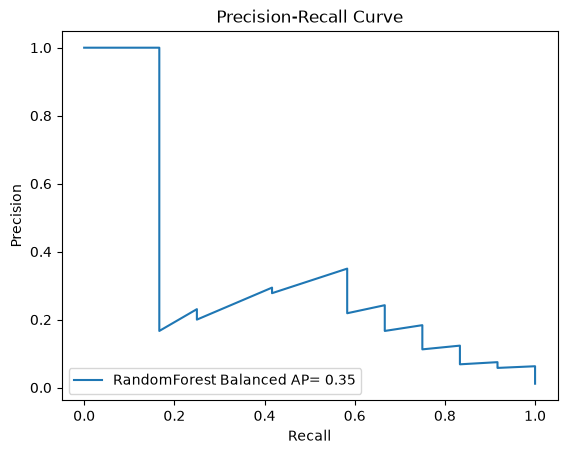

,Model,Defect Precision,Defect Recall,Defect F1 Score,Average Precision
0,RandomForest Baseline,0.294118,0.416667,0.344828,0.444250
1,Bagging Baseline,0.368421,0.583333,0.451613,0.441911
2,XGBoost Baseline,0.368421,0.583333,0.451613,0.270144
3,RandomForest Balanced,0.350000,0.583333,0.437500,0.350518


In [13]:
# model_evaluation.py
result_df=evaluate_models(model_dict, x_test_scaled, y_test, result_df)
result_df

RandomForest Balanced - Random Forest Feature Importance


,Feature,Importance
0,Plasticizing_Position,0.089862
1,Mold_Temperature_4,0.069827
2,Max_Injection_Speed,0.069240
3,Plasticizing_Time,0.059280
4,Max_Back_Pressure,0.058143
5,Max_Injection_Pressure,0.054881
6,Injection_Time,0.054359
7,Mold_Temperature_3,0.054119
8,Clamp_Close_Time,0.052856
9,Filling_Time,0.052245


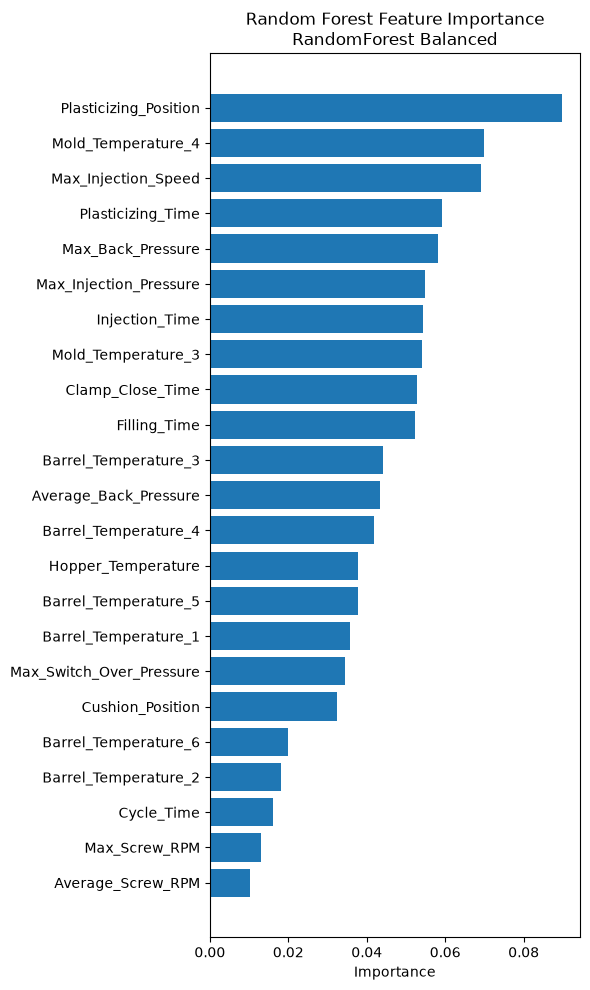

In [14]:
importance_tables = show_random_forest_feature_importance(
    model_dict, x_train.columns
)

### SMOTE: Sampling

#### 데이터 전처리

In [15]:
# 식별 컬럼 제외 (Part는 이 실험에서 쓰지 않음)
drop_columns=['TimeStamp', 'PART_FACT_PLAN_DATE', 'PART_FACT_SERIAL', 'PART_NAME', 'EQUIP_CD', 'Part']

final_df=model_data.drop(columns=drop_columns)

# 데이터 분할
x=final_df.drop(columns='PassOrFail')
y=final_df['PassOrFail']

x_train, x_test, y_train, y_test=train_test_split(x, y, test_size=0.2, stratify=y, random_state=0)

scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

# 학습데이터에 SMOTE 적용
from imblearn.over_sampling import SMOTE

smote=SMOTE(random_state=0)
print("Before")
print(x_train_scaled.shape, y_train.shape)

x_train_smote, y_train_smote=smote.fit_resample(x_train_scaled, y_train)
print("After")
print(x_train_smote.shape, y_train_smote.shape)

Before
(4184, 23) (4184,)


After
(8272, 23) (8272,)


#### 모델 학습

In [16]:
# 학습 모델 저장
model_dict={} # evaluate_models가 for 문으로 작동하기 때문에 초기화 필요

# Random Forest
smote_rf=RandomForestClassifier(n_estimators=1000, random_state=0)
smote_rf.fit(x_train_smote, y_train_smote)
model_dict['RandomForest SMOTE']=smote_rf

# Bagging
smote_bag=BaggingClassifier(n_estimators=1000, random_state=0)
smote_bag.fit(x_train_smote, y_train_smote)
model_dict['Bagging SMOTE']=smote_bag

# XGBoost
smote_xgb=XGBClassifier(n_estimators=1000, random_state=0)
smote_xgb.fit(x_train_smote, y_train_smote)
model_dict['XGBoost SMOTE']=smote_xgb

#### 예측

RandomForest SMOTE
Accuracy: 0.9818355640535373
Average Precision: 0.4152420623110132
Classification Report
              precision    recall  f1-score   support

          양품       0.99      0.99      0.99      1034
          불량       0.29      0.42      0.34        12

    accuracy                           0.98      1046
   macro avg       0.64      0.70      0.67      1046
weighted avg       0.99      0.98      0.98      1046



Bagging SMOTE
Accuracy: 0.9799235181644359
Average Precision: 0.5259476663524639
Classification Report
              precision    recall  f1-score   support

          양품       1.00      0.98      0.99      1034
          불량       0.30      0.58      0.40        12

    accuracy                           0.98      1046
   macro avg       0.65      0.78      0.69      1046
weighted avg       0.99      0.98      0.98      1046

XGBoost SMOTE
Accuracy: 0.9837476099426387
Average Precision: 0.40164969452250154
Classification Report
              precision    recall  f1-score   support

          양품       1.00      0.99      0.99      1034
          불량       0.37      0.58      0.45        12

    accuracy                           0.98      1046
   macro avg       0.68      0.79      0.72      1046
weighted avg       0.99      0.98      0.99      1046



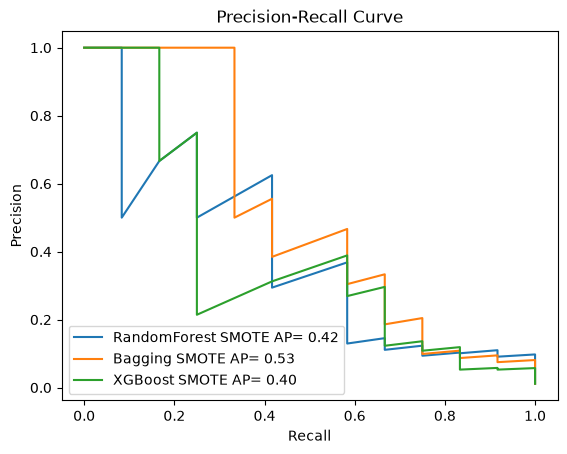

,Model,Defect Precision,Defect Recall,Defect F1 Score,Average Precision
0,RandomForest Baseline,0.294118,0.416667,0.344828,0.444250
1,Bagging Baseline,0.368421,0.583333,0.451613,0.441911
2,XGBoost Baseline,0.368421,0.583333,0.451613,0.270144
3,RandomForest Balanced,0.350000,0.583333,0.437500,0.350518
4,RandomForest SMOTE,0.294118,0.416667,0.344828,0.415242
5,Bagging SMOTE,0.304348,0.583333,0.400000,0.525948
6,XGBoost SMOTE,0.368421,0.583333,0.451613,0.401650


In [17]:
# model_dict의 키를 모델명으로 그대로 사용해 예측 및 평가
result_df = evaluate_models(model_dict, x_test_scaled, y_test, result_df)
result_df

RandomForest SMOTE - Random Forest Feature Importance


,Feature,Importance
0,Max_Injection_Speed,0.087166
1,Plasticizing_Position,0.079820
2,Mold_Temperature_4,0.067682
3,Max_Injection_Pressure,0.065155
4,Clamp_Close_Time,0.060244
5,Max_Back_Pressure,0.059755
6,Cushion_Position,0.052745
7,Mold_Temperature_3,0.051222
8,Filling_Time,0.047594
9,Plasticizing_Time,0.045238


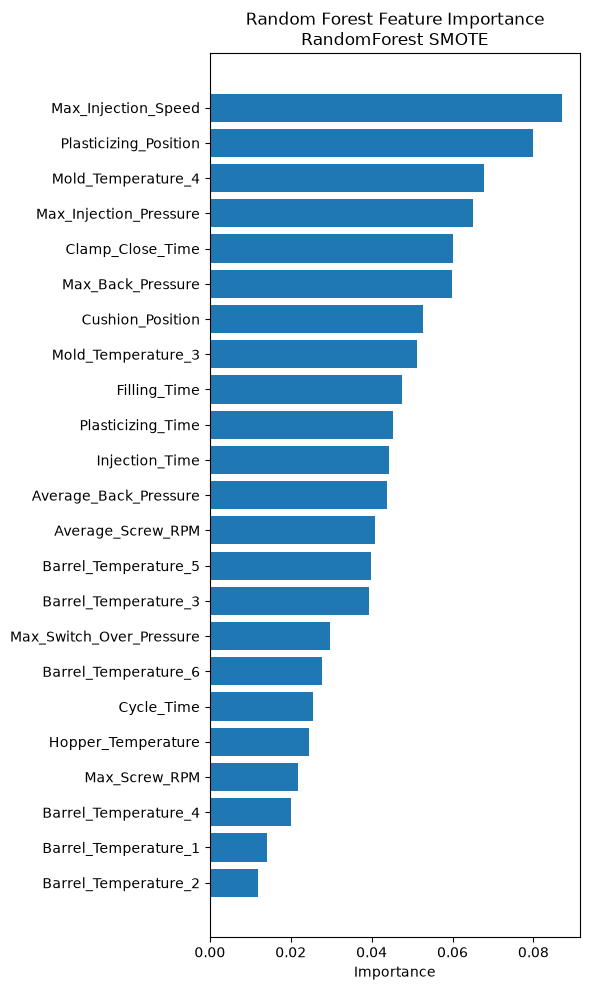

In [18]:
importance_tables=show_random_forest_feature_importance(model_dict, x_train.columns)

#### SMOTE 파라미터 조정

#### 데이터 전처리

In [19]:
# 식별 컬럼 제외 (Part는 이 실험에서 쓰지 않음)
drop_columns=['TimeStamp', 'PART_FACT_PLAN_DATE', 'PART_FACT_SERIAL', 'PART_NAME', 'EQUIP_CD', 'Part']

final_df=model_data.drop(columns=drop_columns)

# 데이터 분할
x=final_df.drop(columns='PassOrFail')
y=final_df['PassOrFail']

x_train, x_test, y_train, y_test=train_test_split(x, y, test_size=0.2, stratify=y, random_state=0)

# 스케일링
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

# SMOTE Sampling_strategy
smote=SMOTE(sampling_strategy=0.1, k_neighbors=3, random_state=0)
print("Before")
print(x_train_scaled.shape, y_train.shape)

x_train_smote, y_train_smote=smote.fit_resample(x_train_scaled, y_train)
print("After")
print(x_train_smote.shape, y_train_smote.shape)

Before
(4184, 23) (4184,)
After
(4549, 23) (4549,)


#### 모델 학습

In [20]:
# 학습 모델 저장
model_dict={}

# Random Forest
smote_rf=RandomForestClassifier(n_estimators=1000, random_state=0)
smote_rf.fit(x_train_smote, y_train_smote)
model_dict['RandomForest SMOTE St=0.1']=smote_rf

# Bagging
smote_bag=BaggingClassifier(n_estimators=1000, random_state=0)
smote_bag.fit(x_train_smote, y_train_smote)
model_dict['Bagging SMOTE St=0.1']=smote_bag

# XGBoost
smote_xgb=XGBClassifier(n_estimators=1000, random_state=0)
smote_xgb.fit(x_train_smote, y_train_smote)
model_dict['XGBoost SMOTE St=0.1']=smote_xgb

#### 예측

RandomForest SMOTE St=0.1
Accuracy: 0.9837476099426387
Average Precision: 0.43203294761172295
Classification Report
              precision    recall  f1-score   support

          양품       1.00      0.99      0.99      1034
          불량       0.37      0.58      0.45        12

    accuracy                           0.98      1046
   macro avg       0.68      0.79      0.72      1046
weighted avg       0.99      0.98      0.99      1046



Bagging SMOTE St=0.1
Accuracy: 0.9837476099426387
Average Precision: 0.41219027907924805
Classification Report
              precision    recall  f1-score   support

          양품       1.00      0.99      0.99      1034
          불량       0.37      0.58      0.45        12

    accuracy                           0.98      1046
   macro avg       0.68      0.79      0.72      1046
weighted avg       0.99      0.98      0.99      1046

XGBoost SMOTE St=0.1
Accuracy: 0.9818355640535373
Average Precision: 0.35366682824113166
Classification Report
              precision    recall  f1-score   support

          양품       0.99      0.99      0.99      1034
          불량       0.29      0.42      0.34        12

    accuracy                           0.98      1046
   macro avg       0.64      0.70      0.67      1046
weighted avg       0.99      0.98      0.98      1046



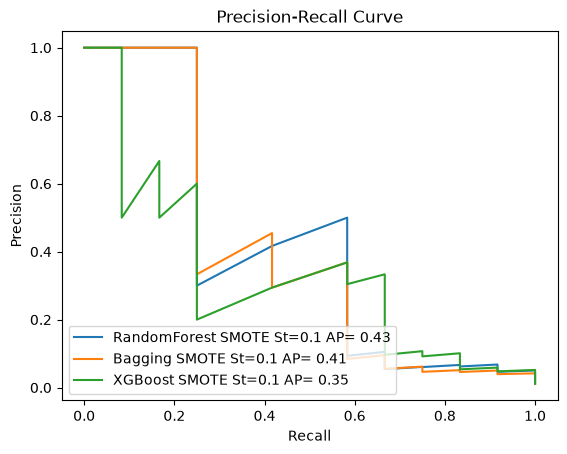

,Model,Defect Precision,Defect Recall,Defect F1 Score,Average Precision
0,RandomForest Baseline,0.294118,0.416667,0.344828,0.444250
1,Bagging Baseline,0.368421,0.583333,0.451613,0.441911
2,XGBoost Baseline,0.368421,0.583333,0.451613,0.270144
3,RandomForest Balanced,0.350000,0.583333,0.437500,0.350518
4,RandomForest SMOTE,0.294118,0.416667,0.344828,0.415242
5,Bagging SMOTE,0.304348,0.583333,0.400000,0.525948
6,XGBoost SMOTE,0.368421,0.583333,0.451613,0.401650
7,RandomForest SMOTE St=0.1,0.368421,0.583333,0.451613,0.432033
8,Bagging SMOTE St=0.1,0.368421,0.583333,0.451613,0.412190
9,XGBoost SMOTE St=0.1,0.294118,0.416667,0.344828,0.353667


In [21]:
# model_dict의 키를 모델명으로 그대로 사용해 예측 및 평가
result_df = evaluate_models(model_dict, x_test_scaled, y_test, result_df)
result_df

RandomForest SMOTE St=0.1 - Random Forest Feature Importance


,Feature,Importance
0,Cushion_Position,0.079996
1,Max_Injection_Speed,0.067043
2,Max_Injection_Pressure,0.059459
3,Average_Screw_RPM,0.056041
4,Clamp_Close_Time,0.052301
5,Mold_Temperature_4,0.052145
6,Plasticizing_Time,0.051010
7,Mold_Temperature_3,0.050670
8,Max_Back_Pressure,0.048713
9,Filling_Time,0.048354


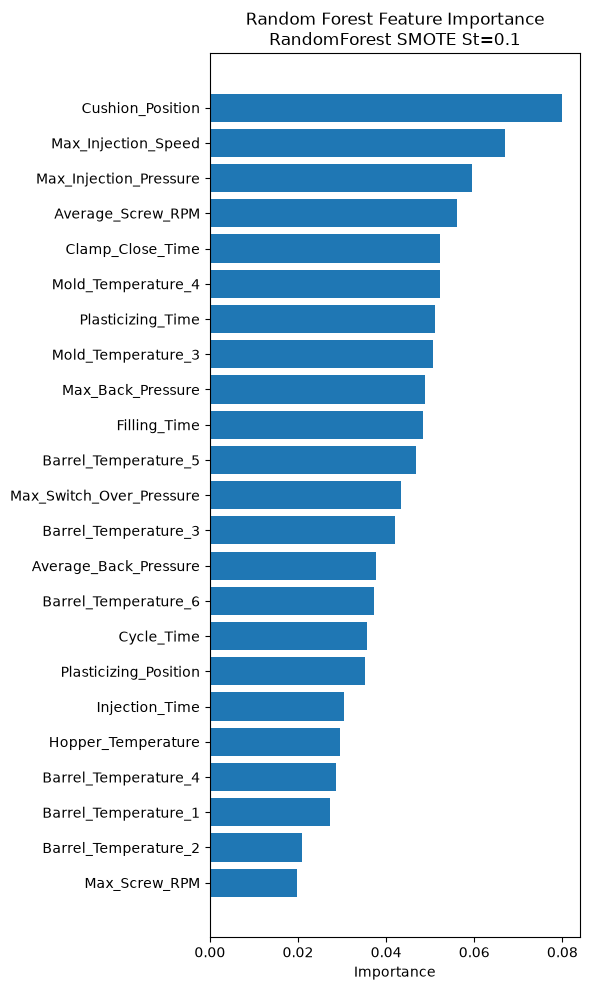

In [22]:
importance_tables = show_random_forest_feature_importance(
    model_dict, x_train.columns
)

### 제품명 변수 추가

#### 데이터 전처리

In [23]:
# CN7, RG3만 구분하는 변수로 다시 만듦 (저장된 Part는 LH/RH까지 구분)
drop_col=model_data.copy()
drop_col['Part']=drop_col['PART_NAME'].str[:3]

# 식별 컬럼 제외
drop_columns=['TimeStamp', 'PART_FACT_PLAN_DATE', 'PART_FACT_SERIAL', 'PART_NAME', 'EQUIP_CD']

drop_col=drop_col.drop(columns=drop_columns)

# 더미변수 생성
final_df = pd.get_dummies(data = drop_col, columns = ['Part'], drop_first=True)
x=final_df.drop(columns='PassOrFail')
y=final_df['PassOrFail']

# 데이터 분할
x_train, x_test, y_train, y_test=train_test_split(x, y, test_size=0.2, stratify=final_df['PassOrFail'], random_state=0)

# 스케일러
scaler=StandardScaler()

x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

#### 모델 학습

In [24]:
model_dict={}
# Random Forest
rf=RandomForestClassifier(n_estimators=1000, random_state=0)
rf.fit(x_train_scaled, y_train)
model_dict['RandomForest PART_NAME_1']=rf

#### 예측

RandomForest PART_NAME_1
Accuracy: 0.9818355640535373
Average Precision: 0.44611041515776056
Classification Report
              precision    recall  f1-score   support

          양품       0.99      0.99      0.99      1034
          불량       0.29      0.42      0.34        12

    accuracy                           0.98      1046
   macro avg       0.64      0.70      0.67      1046
weighted avg       0.99      0.98      0.98      1046



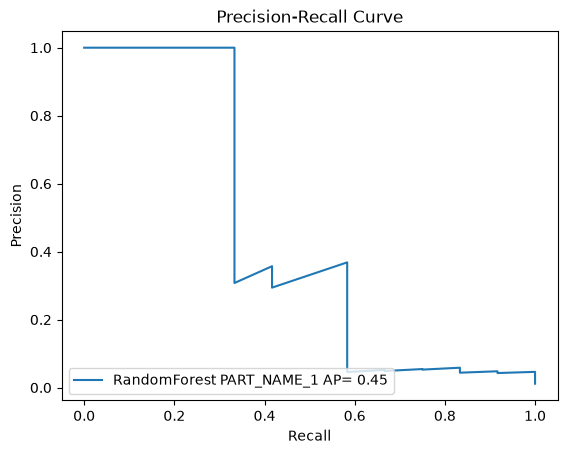

,Model,Defect Precision,Defect Recall,Defect F1 Score,Average Precision
0,RandomForest Baseline,0.294118,0.416667,0.344828,0.444250
1,Bagging Baseline,0.368421,0.583333,0.451613,0.441911
2,XGBoost Baseline,0.368421,0.583333,0.451613,0.270144
3,RandomForest Balanced,0.350000,0.583333,0.437500,0.350518
4,RandomForest SMOTE,0.294118,0.416667,0.344828,0.415242
5,Bagging SMOTE,0.304348,0.583333,0.400000,0.525948
6,XGBoost SMOTE,0.368421,0.583333,0.451613,0.401650
7,RandomForest SMOTE St=0.1,0.368421,0.583333,0.451613,0.432033
8,Bagging SMOTE St=0.1,0.368421,0.583333,0.451613,0.412190
9,XGBoost SMOTE St=0.1,0.294118,0.416667,0.344828,0.353667


In [25]:
result_df = evaluate_models(model_dict, x_test_scaled, y_test, result_df)
result_df

#### 데이터 전처리

In [26]:
# 식별 컬럼 제외
drop_columns=['TimeStamp', 'PART_FACT_PLAN_DATE', 'PART_FACT_SERIAL', 'PART_NAME', 'EQUIP_CD']

drop_col=model_data.drop(columns=drop_columns)

# 더미변수 생성
final_df = pd.get_dummies(data = drop_col, columns = ['Part'], drop_first=True)
x=final_df.drop(columns='PassOrFail')
y=final_df['PassOrFail']

# 데이터 분할
x_train, x_test, y_train, y_test=train_test_split(x, y, test_size=0.2, stratify=final_df['PassOrFail'], random_state=0)

# 스케일러
scaler=StandardScaler()

x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

# 데이터 분할
x_train, x_test, y_train, y_test=train_test_split(final_df.drop(columns='PassOrFail'), final_df['PassOrFail'], test_size=0.2, stratify=final_df['PassOrFail'], random_state=0)

# 스케일러
scaler=StandardScaler()

x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

#### 모델 학습

In [27]:
model_dict={}
# Random Forest
rf=RandomForestClassifier(n_estimators=1000, random_state=0)
rf.fit(x_train_scaled, y_train)
model_dict['RandomForest PART_NAME_2']=rf

#### 예측

RandomForest PART_NAME_2
Accuracy: 0.9875717017208413
Average Precision: 0.5171499667795638
Classification Report
              precision    recall  f1-score   support

          양품       0.99      0.99      0.99      1034
          불량       0.45      0.42      0.43        12

    accuracy                           0.99      1046
   macro avg       0.72      0.71      0.71      1046
weighted avg       0.99      0.99      0.99      1046



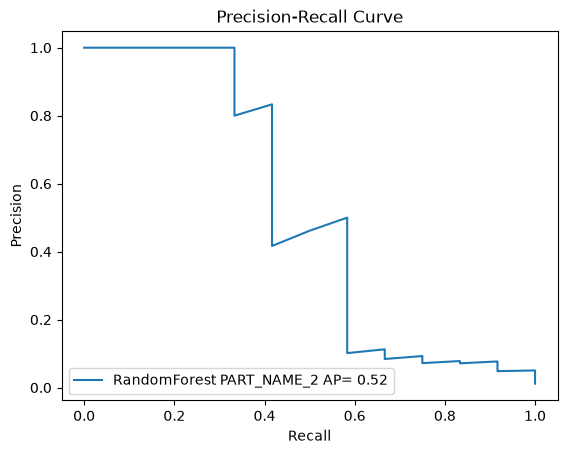

,Model,Defect Precision,Defect Recall,Defect F1 Score,Average Precision
0,RandomForest Baseline,0.294118,0.416667,0.344828,0.444250
1,Bagging Baseline,0.368421,0.583333,0.451613,0.441911
2,XGBoost Baseline,0.368421,0.583333,0.451613,0.270144
3,RandomForest Balanced,0.350000,0.583333,0.437500,0.350518
4,RandomForest SMOTE,0.294118,0.416667,0.344828,0.415242
5,Bagging SMOTE,0.304348,0.583333,0.400000,0.525948
6,XGBoost SMOTE,0.368421,0.583333,0.451613,0.401650
7,RandomForest SMOTE St=0.1,0.368421,0.583333,0.451613,0.432033
8,Bagging SMOTE St=0.1,0.368421,0.583333,0.451613,0.412190
9,XGBoost SMOTE St=0.1,0.294118,0.416667,0.344828,0.353667


In [28]:
result_df = evaluate_models(model_dict, x_test_scaled, y_test, result_df)
result_df

RandomForest PART_NAME_2 - Random Forest Feature Importance


,Feature,Importance
0,Barrel_Temperature_1,0.054753
1,Cushion_Position,0.054304
2,Max_Injection_Speed,0.053218
3,Barrel_Temperature_4,0.051952
4,Max_Switch_Over_Pressure,0.050091
5,Mold_Temperature_4,0.048621
6,Hopper_Temperature,0.048242
7,Max_Back_Pressure,0.045434
8,Barrel_Temperature_2,0.044425
9,Max_Injection_Pressure,0.043992


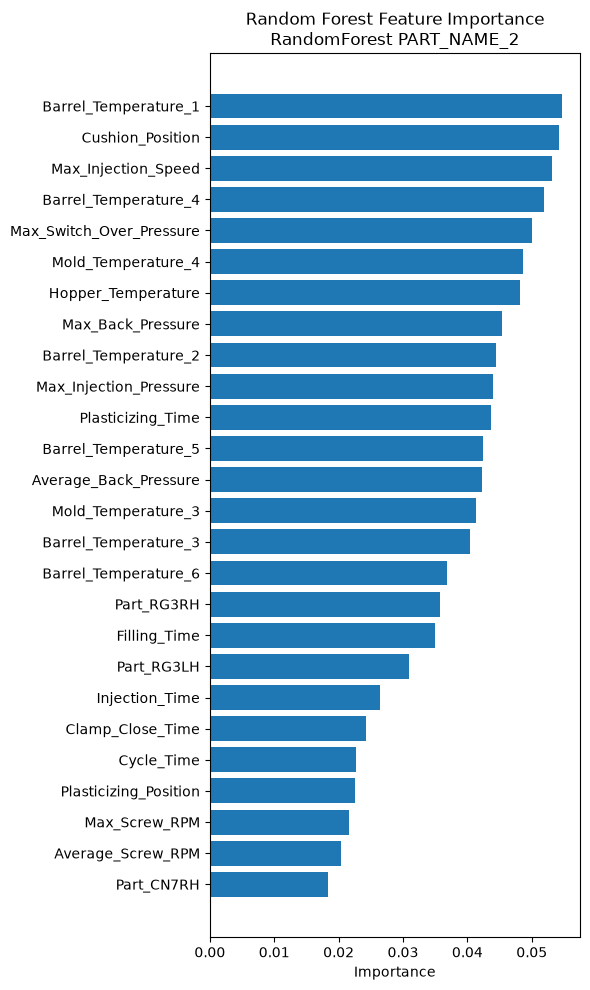

In [29]:
importance_tables = show_random_forest_feature_importance(
    model_dict, x_train.columns
)

### PART_NAME + Class Weight

#### 데이터 전처리

In [30]:
# 식별 컬럼 제외
drop_columns=['TimeStamp', 'PART_FACT_PLAN_DATE', 'PART_FACT_SERIAL', 'PART_NAME', 'EQUIP_CD']

drop_col=model_data.drop(columns=drop_columns)

# 더미변수 생성
final_df = pd.get_dummies(data = drop_col, columns = ['Part'], drop_first=True)
x=final_df.drop(columns='PassOrFail')
y=final_df['PassOrFail']

# 데이터 분할
x_train, x_test, y_train, y_test=train_test_split(x, y, test_size=0.2, stratify=final_df['PassOrFail'], random_state=0)

# 스케일러
scaler=StandardScaler()

x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

#### 모델 학습

In [31]:
model_dict={}
# Random Forest
rf=RandomForestClassifier(n_estimators=1000, class_weight='balanced', min_samples_leaf=2, n_jobs=1,random_state=0)
rf.fit(x_train_scaled, y_train)
model_dict['RandomForest PART_NAME + Balanced']=rf

#### 예측

RandomForest PART_NAME + Balanced
Accuracy: 0.988527724665392
Average Precision: 0.5969131562881563
Classification Report
              precision    recall  f1-score   support

          양품       1.00      0.99      0.99      1034
          불량       0.50      0.67      0.57        12

    accuracy                           0.99      1046
   macro avg       0.75      0.83      0.78      1046
weighted avg       0.99      0.99      0.99      1046



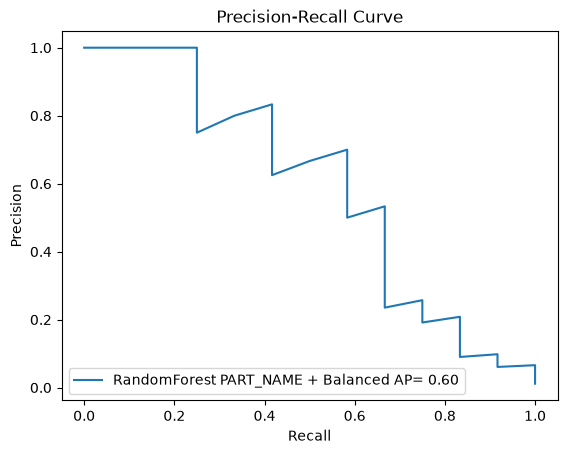

,Model,Defect Precision,Defect Recall,Defect F1 Score,Average Precision
0,RandomForest Baseline,0.294118,0.416667,0.344828,0.444250
1,Bagging Baseline,0.368421,0.583333,0.451613,0.441911
2,XGBoost Baseline,0.368421,0.583333,0.451613,0.270144
3,RandomForest Balanced,0.350000,0.583333,0.437500,0.350518
4,RandomForest SMOTE,0.294118,0.416667,0.344828,0.415242
5,Bagging SMOTE,0.304348,0.583333,0.400000,0.525948
6,XGBoost SMOTE,0.368421,0.583333,0.451613,0.401650
7,RandomForest SMOTE St=0.1,0.368421,0.583333,0.451613,0.432033
8,Bagging SMOTE St=0.1,0.368421,0.583333,0.451613,0.412190
9,XGBoost SMOTE St=0.1,0.294118,0.416667,0.344828,0.353667


In [32]:
result_df = evaluate_models(model_dict, x_test_scaled, y_test, result_df)
result_df

RandomForest PART_NAME + Balanced - Random Forest Feature Importance


,Feature,Importance
0,Plasticizing_Position,0.086650
1,Max_Injection_Speed,0.071909
2,Injection_Time,0.064572
3,Mold_Temperature_4,0.062162
4,Max_Injection_Pressure,0.057579
5,Plasticizing_Time,0.053890
6,Max_Back_Pressure,0.050966
7,Clamp_Close_Time,0.050150
8,Mold_Temperature_3,0.048579
9,Filling_Time,0.048411


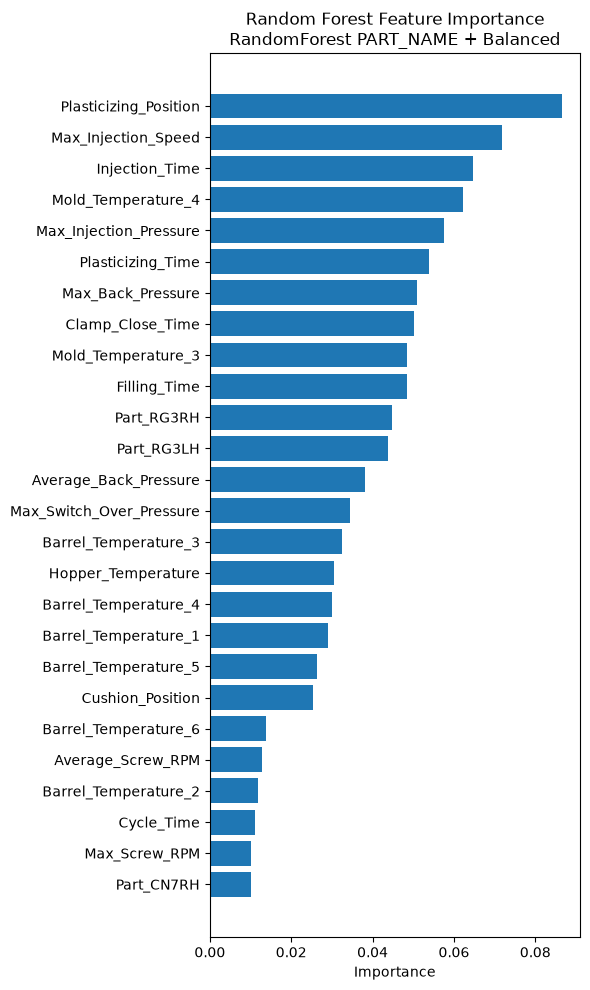

In [33]:
importance_tables = show_random_forest_feature_importance(
    model_dict, x_train.columns
)

### SMOTE + PART_NAME

#### 데이터 전처리

In [34]:
# 식별 컬럼 제외
drop_columns=['TimeStamp', 'PART_FACT_PLAN_DATE', 'PART_FACT_SERIAL', 'PART_NAME', 'EQUIP_CD']

drop_col=model_data.drop(columns=drop_columns)

# 더미변수 생성
final_df = pd.get_dummies(data = drop_col, columns = ['Part'], drop_first=True)
x=final_df.drop(columns='PassOrFail')
y=final_df['PassOrFail']

# 데이터 분할
x_train, x_test, y_train, y_test=train_test_split(x, y, test_size=0.2, stratify=final_df['PassOrFail'], random_state=0)

# 스케일러
scaler=StandardScaler()

x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

# SMOTE
smote=SMOTE(sampling_strategy=0.1, k_neighbors=3, random_state=0)
print("Before")
print(x_train_scaled.shape, y_train.shape)

x_train_smote, y_train_smote=smote.fit_resample(x_train_scaled, y_train)
print("After")
print(x_train_smote.shape, y_train_smote.shape)

Before
(4184, 26) (4184,)
After
(4549, 26) (4549,)


#### 모델 학습

In [35]:
# 학습 모델 저장
model_dict={}

# Random Forest
smote_rf=RandomForestClassifier(n_estimators=1000, random_state=0)
smote_rf.fit(x_train_smote, y_train_smote)
model_dict['RandomForest PART_NAME+SMOTE St=0.1']=smote_rf

# Bagging
smote_bag=BaggingClassifier(n_estimators=1000, random_state=0)
smote_bag.fit(x_train_smote, y_train_smote)
model_dict['Bagging PART_NAME+SMOTE St=0.1']=smote_bag

# XGBoost
smote_xgb=XGBClassifier(n_estimators=1000, random_state=0)
smote_xgb.fit(x_train_smote, y_train_smote)
model_dict['XGBoost PART_NAME+SMOTE St=0.1']=smote_xgb

#### 예측

RandomForest PART_NAME+SMOTE St=0.1
Accuracy: 0.9904397705544933
Average Precision: 0.6445883510540761
Classification Report
              precision    recall  f1-score   support

          양품       1.00      1.00      1.00      1034
          불량       0.58      0.58      0.58        12

    accuracy                           0.99      1046
   macro avg       0.79      0.79      0.79      1046
weighted avg       0.99      0.99      0.99      1046



Bagging PART_NAME+SMOTE St=0.1
Accuracy: 0.988527724665392
Average Precision: 0.6260515677835249
Classification Report
              precision    recall  f1-score   support

          양품       1.00      0.99      0.99      1034
          불량       0.50      0.58      0.54        12

    accuracy                           0.99      1046
   macro avg       0.75      0.79      0.77      1046
weighted avg       0.99      0.99      0.99      1046

XGBoost PART_NAME+SMOTE St=0.1
Accuracy: 0.9904397705544933
Average Precision: 0.5097266205332707
Classification Report
              precision    recall  f1-score   support

          양품       0.99      1.00      1.00      1034
          불량       0.62      0.42      0.50        12

    accuracy                           0.99      1046
   macro avg       0.81      0.71      0.75      1046
weighted avg       0.99      0.99      0.99      1046



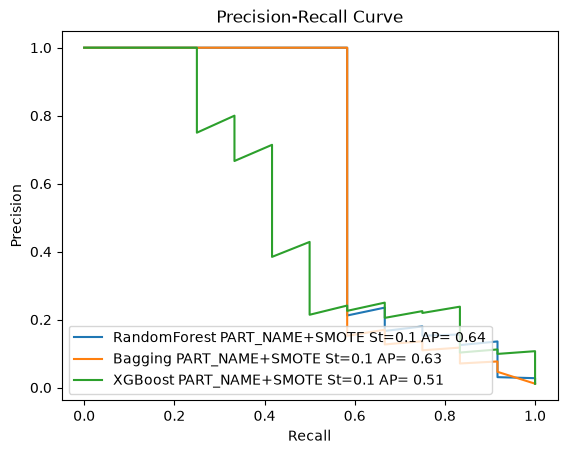

,Model,Defect Precision,Defect Recall,Defect F1 Score,Average Precision
0,RandomForest Baseline,0.294118,0.416667,0.344828,0.444250
1,Bagging Baseline,0.368421,0.583333,0.451613,0.441911
2,XGBoost Baseline,0.368421,0.583333,0.451613,0.270144
3,RandomForest Balanced,0.350000,0.583333,0.437500,0.350518
4,RandomForest SMOTE,0.294118,0.416667,0.344828,0.415242
5,Bagging SMOTE,0.304348,0.583333,0.400000,0.525948
6,XGBoost SMOTE,0.368421,0.583333,0.451613,0.401650
7,RandomForest SMOTE St=0.1,0.368421,0.583333,0.451613,0.432033
8,Bagging SMOTE St=0.1,0.368421,0.583333,0.451613,0.412190
9,XGBoost SMOTE St=0.1,0.294118,0.416667,0.344828,0.353667


In [36]:
# model_dict의 키를 모델명으로 그대로 사용해 예측 및 평가
result_df = evaluate_models(model_dict, x_test_scaled, y_test, result_df)
result_df

RandomForest PART_NAME+SMOTE St=0.1 - Random Forest Feature Importance


,Feature,Importance
0,Cushion_Position,0.073325
1,Max_Injection_Speed,0.065258
2,Clamp_Close_Time,0.057540
3,Max_Injection_Pressure,0.056738
4,Part_RG3RH,0.051867
5,Average_Screw_RPM,0.051677
6,Mold_Temperature_3,0.050773
7,Barrel_Temperature_5,0.046126
8,Mold_Temperature_4,0.045823
9,Plasticizing_Time,0.045085


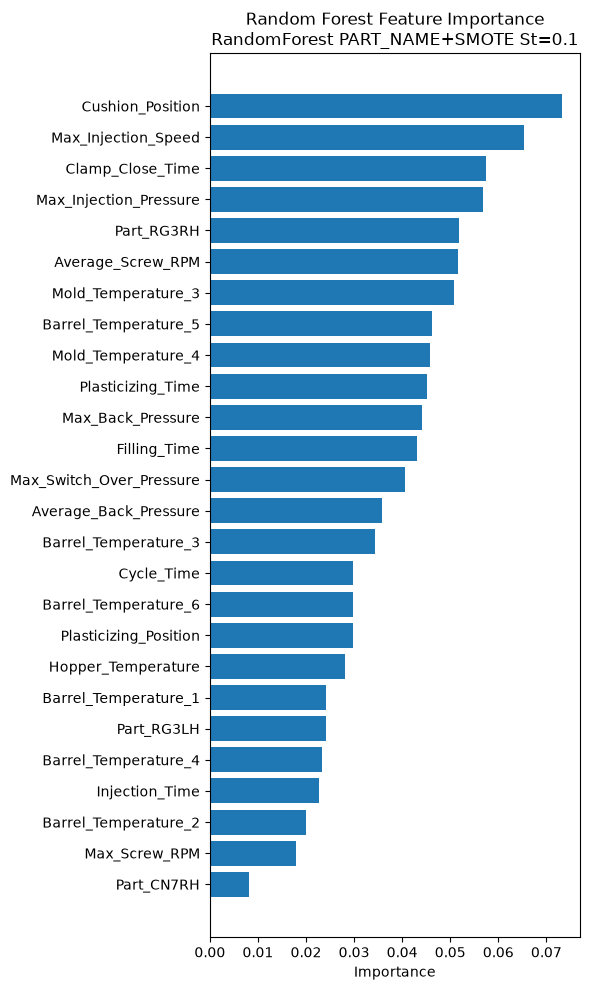

In [37]:
# model_dict에 다른 모델이 있어도 Random Forest만 표와 그래프로 출력
importance_tables = show_random_forest_feature_importance(model_dict, x_train.columns)

### SMOTE + Class Weight

#### 데이터 전처리

In [38]:
# 식별 컬럼 제외 (Part는 이 실험에서 쓰지 않음)
drop_columns=['TimeStamp', 'PART_FACT_PLAN_DATE', 'PART_FACT_SERIAL', 'PART_NAME', 'EQUIP_CD', 'Part']

final_df=model_data.drop(columns=drop_columns)

# 데이터 분할
x=final_df.drop(columns='PassOrFail')
y=final_df['PassOrFail']

x_train, x_test, y_train, y_test=train_test_split(x, y, test_size=0.2, stratify=y, random_state=0)

# 스케일링
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

# SMOTE Sampling_strategy
smote=SMOTE(sampling_strategy=0.1, k_neighbors=3, random_state=0)
print("Before")
print(x_train_scaled.shape, y_train.shape)

x_train_smote, y_train_smote=smote.fit_resample(x_train_scaled, y_train)
print("After")
print(x_train_smote.shape, y_train_smote.shape)

Before
(4184, 23) (4184,)
After
(4549, 23) (4549,)


#### 모델 학습

In [39]:
model_dict={}
# Random Forest
rf=RandomForestClassifier(n_estimators=1000, class_weight='balanced', min_samples_leaf=2, n_jobs=1,random_state=0)
rf.fit(x_train_smote, y_train_smote)
model_dict['RandomForest SMOTE St=0.1 + Balanced']=rf

#### 예측

RandomForest SMOTE St=0.1 + Balanced
Accuracy: 0.9837476099426387
Average Precision: 0.40587385805161397
Classification Report
              precision    recall  f1-score   support

          양품       1.00      0.99      0.99      1034
          불량       0.37      0.58      0.45        12

    accuracy                           0.98      1046
   macro avg       0.68      0.79      0.72      1046
weighted avg       0.99      0.98      0.99      1046



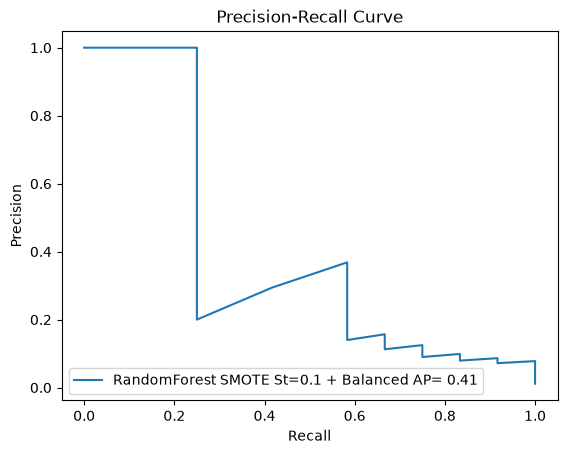

,Model,Defect Precision,Defect Recall,Defect F1 Score,Average Precision
0,RandomForest Baseline,0.294118,0.416667,0.344828,0.444250
1,Bagging Baseline,0.368421,0.583333,0.451613,0.441911
2,XGBoost Baseline,0.368421,0.583333,0.451613,0.270144
3,RandomForest Balanced,0.350000,0.583333,0.437500,0.350518
4,RandomForest SMOTE,0.294118,0.416667,0.344828,0.415242
5,Bagging SMOTE,0.304348,0.583333,0.400000,0.525948
6,XGBoost SMOTE,0.368421,0.583333,0.451613,0.401650
7,RandomForest SMOTE St=0.1,0.368421,0.583333,0.451613,0.432033
8,Bagging SMOTE St=0.1,0.368421,0.583333,0.451613,0.412190
9,XGBoost SMOTE St=0.1,0.294118,0.416667,0.344828,0.353667


In [40]:
result_df = evaluate_models(model_dict, x_test_scaled, y_test, result_df)
result_df

RandomForest SMOTE St=0.1 + Balanced - Random Forest Feature Importance


,Feature,Importance
0,Plasticizing_Position,0.085364
1,Max_Injection_Speed,0.080402
2,Max_Back_Pressure,0.071546
3,Clamp_Close_Time,0.063228
4,Max_Injection_Pressure,0.059217
5,Mold_Temperature_4,0.058205
6,Average_Back_Pressure,0.057937
7,Mold_Temperature_3,0.055952
8,Plasticizing_Time,0.046309
9,Filling_Time,0.044780


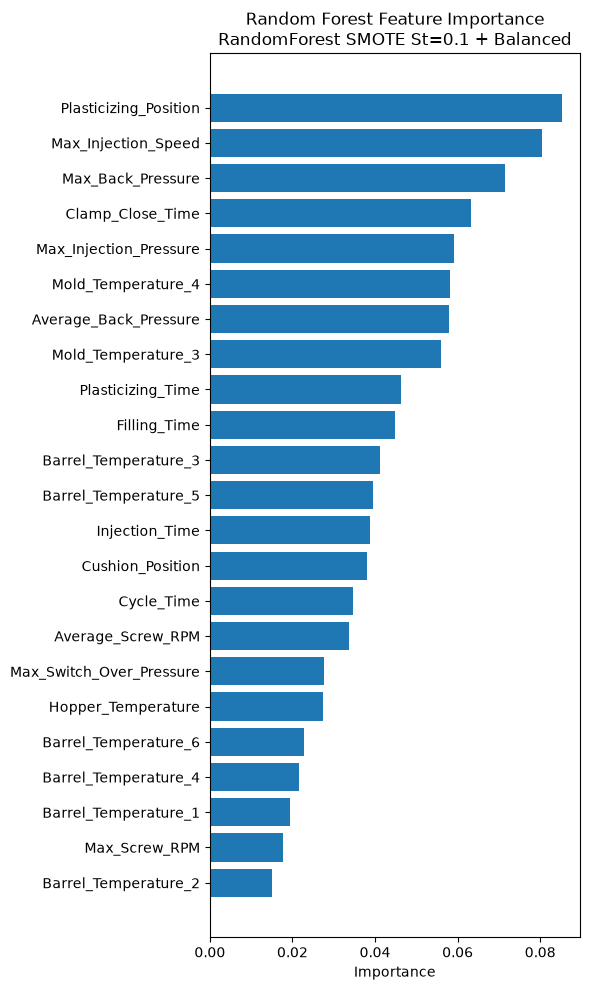

In [41]:
importance_tables = show_random_forest_feature_importance(
    model_dict, x_train.columns
)

### SMOTE + PART_NAME + Class Weight

#### 데이터 전처리

In [42]:
# 식별 컬럼 제외
drop_columns=['TimeStamp', 'PART_FACT_PLAN_DATE', 'PART_FACT_SERIAL', 'PART_NAME', 'EQUIP_CD']

drop_col=model_data.drop(columns=drop_columns)

# 더미변수 생성
final_df = pd.get_dummies(data = drop_col, columns = ['Part'], drop_first=True)
x=final_df.drop(columns='PassOrFail')
y=final_df['PassOrFail']

# 데이터 분할
x_train, x_test, y_train, y_test=train_test_split(x, y, test_size=0.2, stratify=final_df['PassOrFail'], random_state=0)

# 스케일러
scaler=StandardScaler()

x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

# SMOTE
smote=SMOTE(sampling_strategy=0.1, k_neighbors=3, random_state=0)
print("Before")
print(x_train_scaled.shape, y_train.shape)

x_train_smote, y_train_smote=smote.fit_resample(x_train_scaled, y_train)
print("After")
print(x_train_smote.shape, y_train_smote.shape)

Before
(4184, 26) (4184,)
After
(4549, 26) (4549,)


#### 모델 학습

In [43]:
# 학습 모델 저장
model_dict={}

# Random Forest
smote_rf=RandomForestClassifier(n_estimators=1000, class_weight='balanced', min_samples_leaf=2, n_jobs=1,random_state=0)
smote_rf.fit(x_train_smote, y_train_smote)
model_dict['RandomForest PART_NAME+SMOTE St=0.1+Balanced']=smote_rf

RandomForest PART_NAME+SMOTE St=0.1+Balanced
Accuracy: 0.9837476099426387
Average Precision: 0.5530095037526933
Classification Report
              precision    recall  f1-score   support

          양품       1.00      0.99      0.99      1034
          불량       0.37      0.58      0.45        12

    accuracy                           0.98      1046
   macro avg       0.68      0.79      0.72      1046
weighted avg       0.99      0.98      0.99      1046



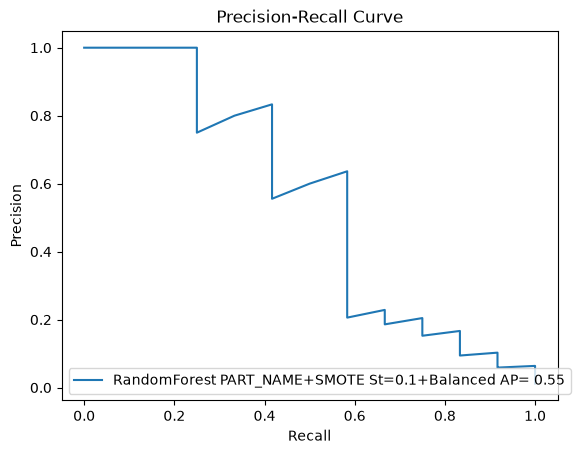

,Model,Defect Precision,Defect Recall,Defect F1 Score,Average Precision
0,RandomForest Baseline,0.294118,0.416667,0.344828,0.444250
1,Bagging Baseline,0.368421,0.583333,0.451613,0.441911
2,XGBoost Baseline,0.368421,0.583333,0.451613,0.270144
3,RandomForest Balanced,0.350000,0.583333,0.437500,0.350518
4,RandomForest SMOTE,0.294118,0.416667,0.344828,0.415242
5,Bagging SMOTE,0.304348,0.583333,0.400000,0.525948
6,XGBoost SMOTE,0.368421,0.583333,0.451613,0.401650
7,RandomForest SMOTE St=0.1,0.368421,0.583333,0.451613,0.432033
8,Bagging SMOTE St=0.1,0.368421,0.583333,0.451613,0.412190
9,XGBoost SMOTE St=0.1,0.294118,0.416667,0.344828,0.353667


In [44]:
# model_dict의 키를 모델명으로 그대로 사용해 예측 및 평가
result_df = evaluate_models(model_dict, x_test_scaled, y_test, result_df)
result_df

RandomForest PART_NAME+SMOTE St=0.1+Balanced - Random Forest Feature Importance


,Feature,Importance
0,Max_Injection_Speed,0.090862
1,Plasticizing_Position,0.076420
2,Max_Back_Pressure,0.068403
3,Max_Injection_Pressure,0.065279
4,Clamp_Close_Time,0.059859
5,Average_Back_Pressure,0.058173
6,Mold_Temperature_4,0.054861
7,Mold_Temperature_3,0.052129
8,Plasticizing_Time,0.049233
9,Filling_Time,0.044576


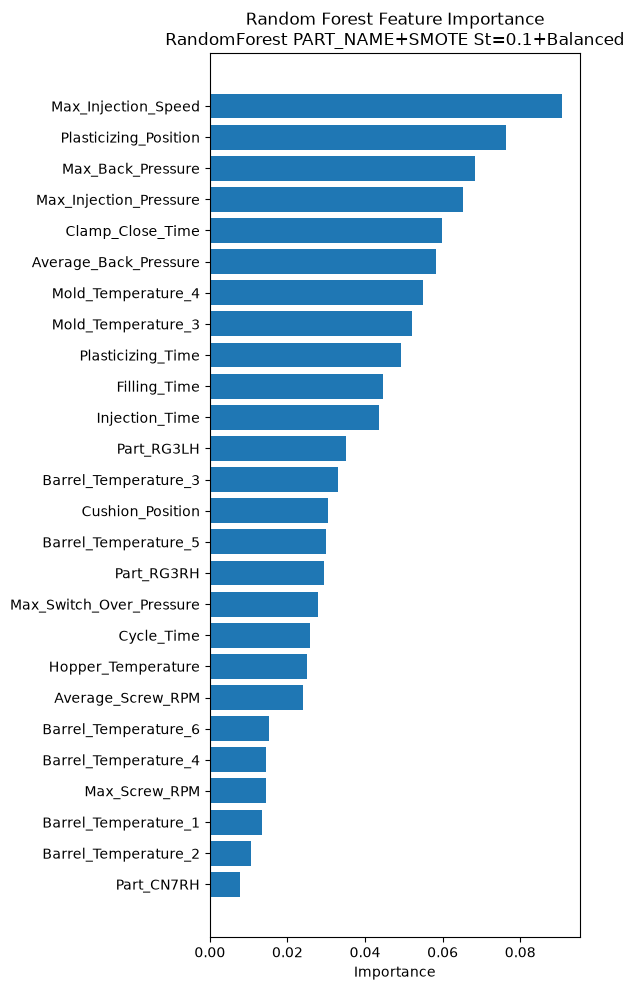

In [45]:
# model_dict에 다른 모델이 있어도 Random Forest만 표와 그래프로 출력
importance_tables = show_random_forest_feature_importance(model_dict, x_train.columns)

### PART_NAME + SMOTE + 파생변수 추가

#### 데이터 전처리

In [46]:
# TimeStamp 정렬
sort_df=model_data.sort_values('TimeStamp', ignore_index=True)

# 식별 컬럼 제외 (EQUIP_CD, PART_NAME은 이동 통계 기준으로 뒤에서 사용)
drop_columns=['TimeStamp', 'PART_FACT_PLAN_DATE', 'PART_FACT_SERIAL']

drop_col=sort_df.drop(columns=drop_columns)

# 더미변수 생성
final_df = pd.get_dummies(data = drop_col, columns = ['Part'], drop_first=True)

# 파생변수 추가
final_df['Barrel_Temp_Range']=(final_df[[f'Barrel_Temperature_{i}' for i in range(1, 7)]].max(axis=1)
                                      - final_df[[f'Barrel_Temperature_{i}' for i in range(1, 7)]].min(axis=1))

final_df['Barrel_Temp_Std'] = final_df[[f'Barrel_Temperature_{i}' for i in range(1, 7)]].std(axis=1)

final_df['Mold_Temp_Range']=(final_df[[f'Mold_Temperature_{i}' for i in range(3, 5)]].max(axis=1)
                                      - final_df[[f'Mold_Temperature_{i}' for i in range(3, 5)]].min(axis=1))

final_df['Mold_Temp_Std'] = final_df[[f'Mold_Temperature_{i}' for i in range(3, 5)]].std(axis=1)

for col in ['Injection_Time', 'Cycle_Time',
            'Max_Injection_Pressure', 'Cushion_Position']:
    final_df[f'{col}_diff'] = final_df.groupby(['EQUIP_CD', 'PART_NAME'])[col].diff()
    final_df[f'{col}_rolling_mean_5'] = final_df.groupby(['EQUIP_CD', 'PART_NAME'])[col].transform(lambda x: x.shift(1).rolling(5, min_periods=1).mean())
    final_df[f'{col}_rolling_std_5'] = final_df.groupby(['EQUIP_CD', 'PART_NAME'])[col].transform(lambda x: x.shift(1).rolling(5, min_periods=1).std())

drop_columns=['EQUIP_CD', 'PART_NAME']
final_df=final_df.drop(columns=drop_columns)
final_df=final_df.dropna(ignore_index=True)

x=final_df.drop(columns='PassOrFail')
y=final_df['PassOrFail']

# 데이터 분할
x_train, x_test, y_train, y_test=train_test_split(x, y, test_size=0.2, stratify=y, random_state=0)

# 스케일러
scaler=StandardScaler()

x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

# SMOTE
smote=SMOTE(sampling_strategy=0.1, k_neighbors=3, random_state=0)
print("Before")
print(x_train_scaled.shape, y_train.shape)

x_train_smote, y_train_smote=smote.fit_resample(x_train_scaled, y_train)
print("After")
print(x_train_smote.shape, y_train_smote.shape)

Before
(4177, 42) (4177,)
After
(4541, 42) (4541,)


#### 모델 학습

In [47]:
# 학습 모델 저장
model_dict={}

# Random Forest
rf=RandomForestClassifier(n_estimators=1000, random_state=0)
rf.fit(x_train_smote, y_train_smote)
model_dict['RandomForest PART_NAME+SMOTE St=0.1+Feature']=rf

#### 예측

RandomForest PART_NAME+SMOTE St=0.1+Feature
Accuracy: 0.9894736842105263
Average Precision: 0.43256594474458476
Classification Report
              precision    recall  f1-score   support

          양품       0.99      1.00      0.99      1033
          불량       0.57      0.33      0.42        12

    accuracy                           0.99      1045
   macro avg       0.78      0.67      0.71      1045
weighted avg       0.99      0.99      0.99      1045



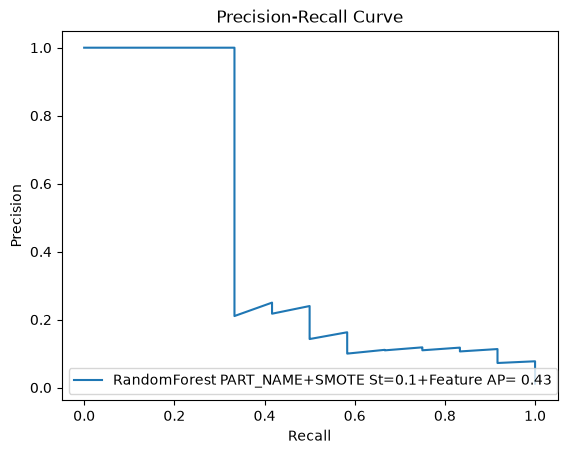

,Model,Defect Precision,Defect Recall,Defect F1 Score,Average Precision
0,RandomForest Baseline,0.294118,0.416667,0.344828,0.444250
1,Bagging Baseline,0.368421,0.583333,0.451613,0.441911
2,XGBoost Baseline,0.368421,0.583333,0.451613,0.270144
3,RandomForest Balanced,0.350000,0.583333,0.437500,0.350518
4,RandomForest SMOTE,0.294118,0.416667,0.344828,0.415242
5,Bagging SMOTE,0.304348,0.583333,0.400000,0.525948
6,XGBoost SMOTE,0.368421,0.583333,0.451613,0.401650
7,RandomForest SMOTE St=0.1,0.368421,0.583333,0.451613,0.432033
8,Bagging SMOTE St=0.1,0.368421,0.583333,0.451613,0.412190
9,XGBoost SMOTE St=0.1,0.294118,0.416667,0.344828,0.353667


In [48]:
# model_dict의 키를 모델명으로 그대로 사용해 예측 및 평가
result_df = evaluate_models(model_dict, x_test_scaled, y_test, result_df)
result_df

RandomForest PART_NAME+SMOTE St=0.1+Feature - Random Forest Feature Importance


,Feature,Importance
0,Cushion_Position,0.053075
1,Injection_Time_rolling_std_5,0.046058
2,Max_Injection_Speed,0.044394
3,Mold_Temperature_3,0.043184
4,Clamp_Close_Time,0.042661
5,Part_RG3RH,0.036584
6,Filling_Time,0.035352
7,Cushion_Position_rolling_std_5,0.034837
8,Max_Back_Pressure,0.033270
9,Max_Injection_Pressure,0.030643


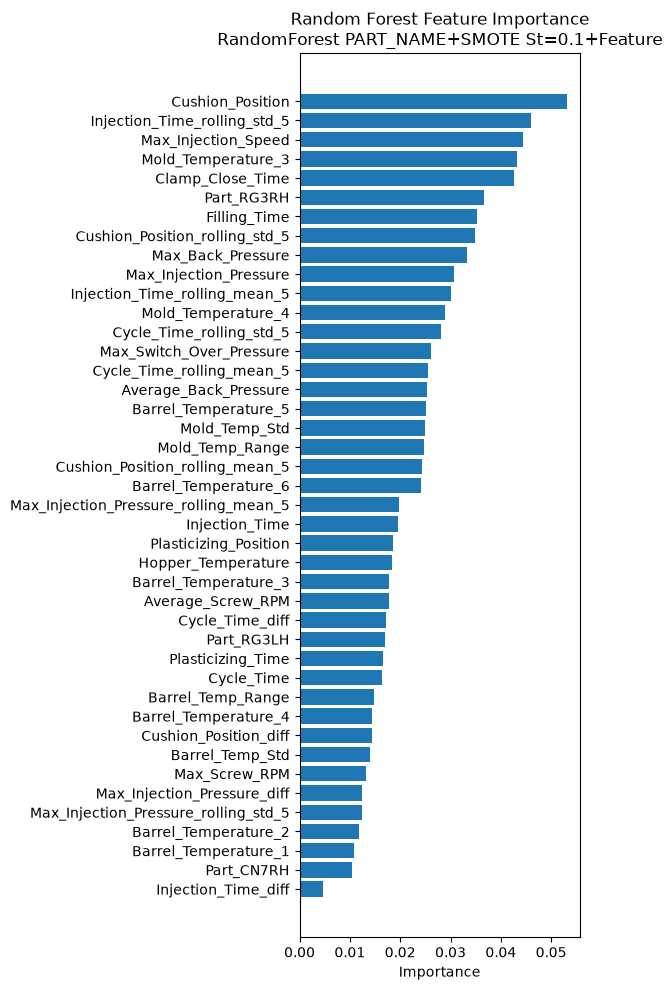

In [49]:
# model_dict에 다른 모델이 있어도 Random Forest만 표와 그래프로 출력
importance_tables = show_random_forest_feature_importance(model_dict, x_train.columns)

# 모델링 결과 요약

In [50]:
result_df.sort_values(['Defect Recall', 'Defect F1 Score', 'Average Precision'], ascending=False)

,Model,Defect Precision,Defect Recall,Defect F1 Score,Average Precision
12,RandomForest PART_NAME + Balanced,0.500000,0.666667,0.571429,0.596913
13,RandomForest PART_NAME+SMOTE St=0.1,0.583333,0.583333,0.583333,0.644588
14,Bagging PART_NAME+SMOTE St=0.1,0.500000,0.583333,0.538462,0.626052
17,RandomForest PART_NAME+SMOTE St=0.1+Balanced,0.368421,0.583333,0.451613,0.553010
7,RandomForest SMOTE St=0.1,0.368421,0.583333,0.451613,0.432033
8,Bagging SMOTE St=0.1,0.368421,0.583333,0.451613,0.412190
16,RandomForest SMOTE St=0.1 + Balanced,0.368421,0.583333,0.451613,0.405874
6,XGBoost SMOTE,0.368421,0.583333,0.451613,0.401650
1,Bagging Baseline,0.368421,0.583333,0.451613,0.441911
2,XGBoost Baseline,0.368421,0.583333,0.451613,0.270144


In [51]:
result_df.to_csv('04_1_Imbalance_and_Feature_Experiments.csv', index=False)